In [1]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, CenteredNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm, Normalize

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3
from scoob_llowfsc import utils
from scoob_llowfsc import llowfsc_sim as llowfsc
import scoob_llowfsc.scoob_model as scoobm
import scoob_llowfsc.detector as detector

wfe_data = utils.load_pickle('sim-data/example_wfe_data.pkl')
iefc_data = utils.load_pickle('sim-data/example_iefc_data.pkl')
dh_command = iefc_data['commands'][-1]

hadamard_svd_data = utils.load_pickle('sim-data/llowfsc_hadamard_svd_data.pkl')
hsvd_dm_modes = hadamard_svd_data['control_modes']
hsvd_wfs_modes = hadamard_svd_data['wfs_modes']

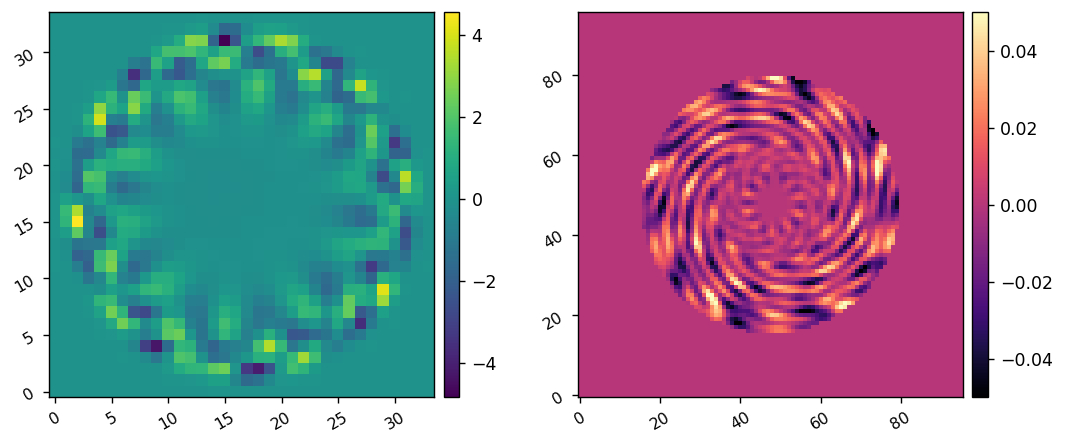

In [2]:
i = 100
vmax = 0.05
imshow2(
    hsvd_dm_modes[i], hsvd_wfs_modes[i], 
    cmap1='viridis', 
    vmin2=-vmax, vmax2=vmax,
)

Oversampling > 2x suggested for reliable results in Fresnel propagation.


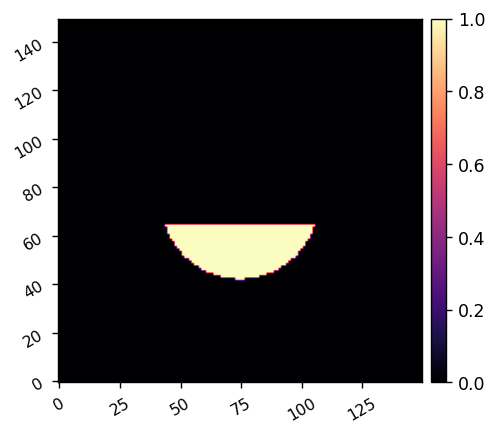

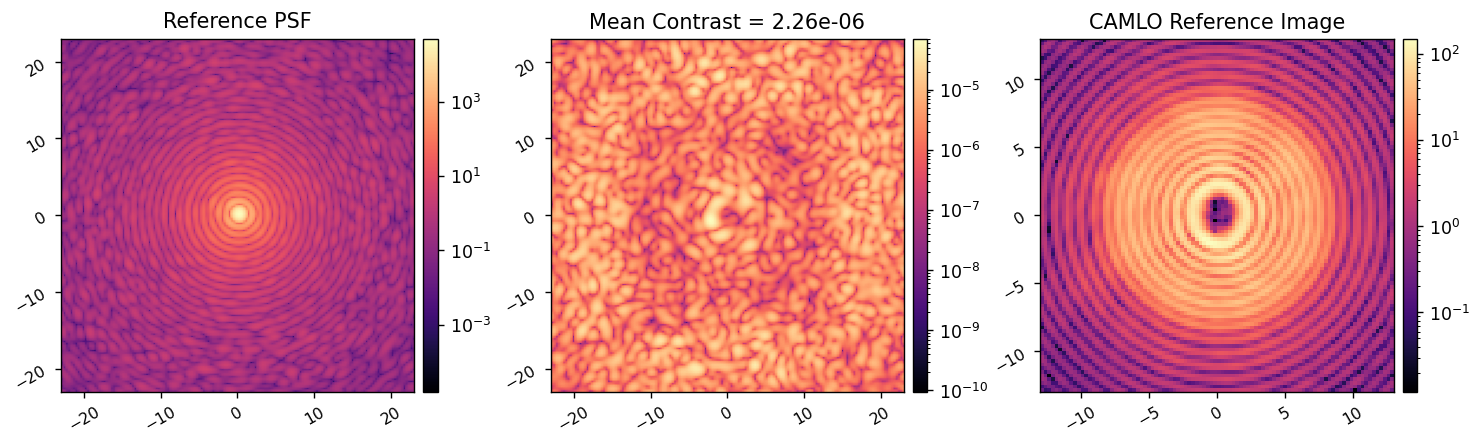

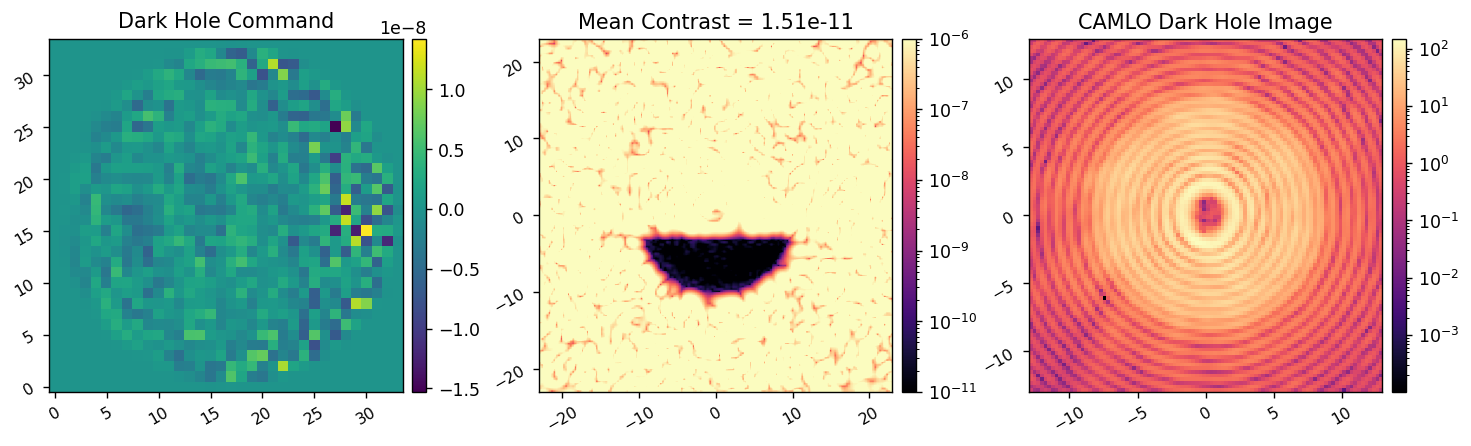

In [2]:
reload(scoobm)
reload(utils)

M = scoobm.single(
    dm_ref=wfe_data['DM_FLAT'],
)
M.reset_dm()
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']

M.POSTFPM_AMP = wfe_data['POSTFPM_AMP']
M.POSTFPM_OPD = wfe_data['POSTFPM_OPD']

M.RLS_AMP = wfe_data['RLS_AMP']
M.RLS_OPD = wfe_data['RLS_OPD']

iwa = 3
owa = 10
dark_hole_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,
    rotation=90,
)
imshow1(dark_hole_mask)

M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
camsci_im_ref = M.snap_camsci()
contrast_ref = xp.mean(camsci_im_ref[dark_hole_mask])

M.llowfsc_defocus = 2.75e-3
camlo_im_ref = M.snap_camlo()

imshow3(
    ref_psf, camsci_im_ref, camlo_im_ref,
    'Reference PSF', f'Mean Contrast = {contrast_ref:.2e}', 'CAMLO Reference Image',
    pxscl1=M.camsci_pxscl_lamDc, pxscl2=M.camsci_pxscl_lamDc, pxscl3=M.camlo_pxscl_lamDc,
    lognorm=1, 
)

M.add_dm(dh_command, 3)
camsci_im_dh0 = M.snap_camsci()
contrast_dh0 = xp.mean(camsci_im_dh0[dark_hole_mask])
camlo_im_dh = M.snap_camlo()
M.add_dm(-dh_command, 3)

imshow3(
    dh_command, camsci_im_dh0, camlo_im_dh,
    'Dark Hole Command', f'Mean Contrast = {contrast_dh0:.2e}', 'CAMLO Dark Hole Image',
    pxscl2=M.camsci_pxscl_lamDc, pxscl3=M.camlo_pxscl_lamDc,
    cmap1='viridis',
    lognorm2=1, vmin2=1e-11, vmax2=1e-6,
    lognorm3=1,
)


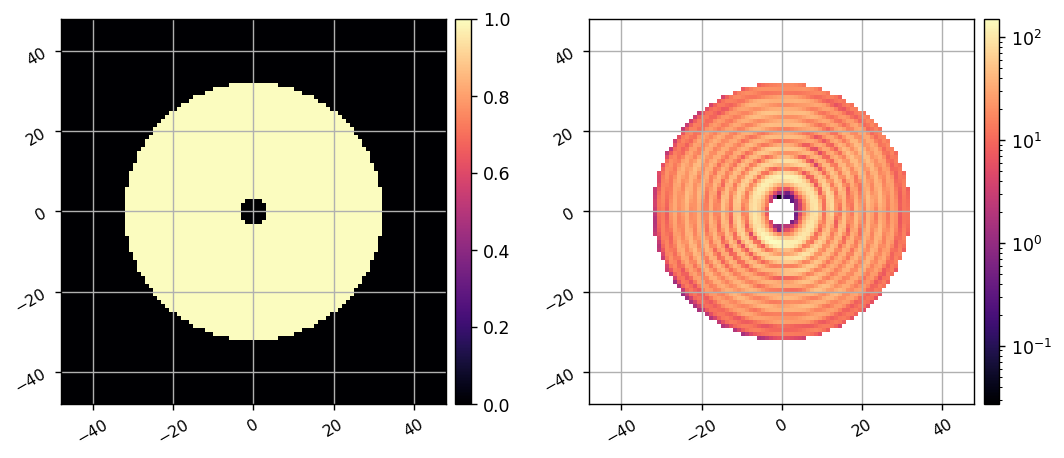

In [3]:
reload(llowfsc)
irad = 3
orad = 32
llowfsc_mask = utils.create_annular_focal_plane_mask(M.ncamlo, 1, irad, orad, edge=None, )
imshow2(llowfsc_mask, camlo_im_ref * llowfsc_mask, grid=True, pxscl=1, lognorm2=True)

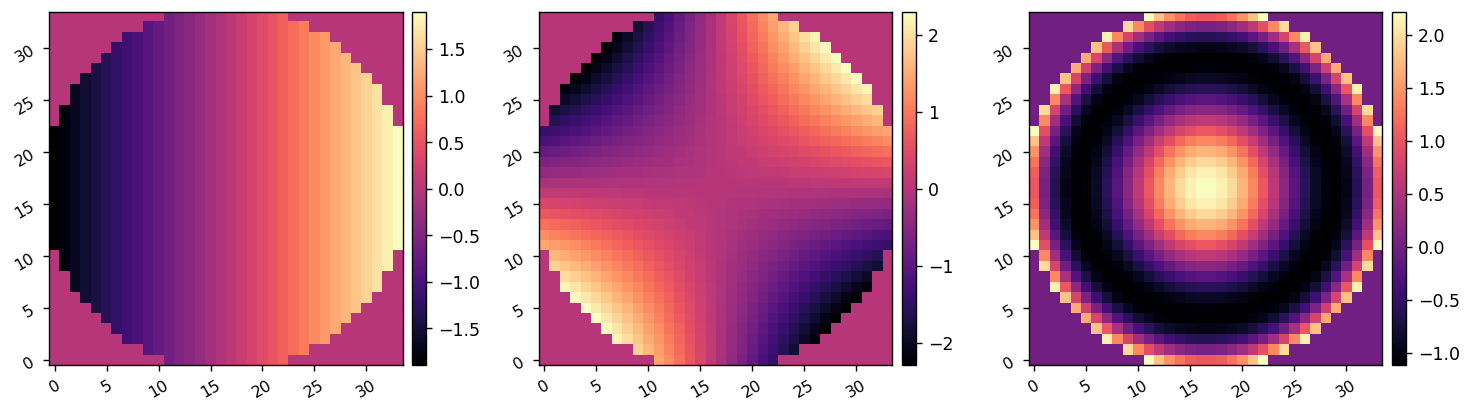

In [4]:
reload(utils)
zernike_modes = utils.create_zernike_modes(M.dm_mask, nmodes=10, remove_modes=1)
zer_modal_matrix = zernike_modes[:, M.dm_mask]
imshow3(zernike_modes[0], zernike_modes[3], zernike_modes[-1])

In [5]:
reload(llowfsc)
M.reset_dm()

M.setattr('use_vortex', True)
z_rm, z_response_cube = llowfsc.calibrate_without_fsm(
    M, 
    zernike_modes, 
    llowfsc_mask, 
    amps=3e-9, 
    # plot=True,
)

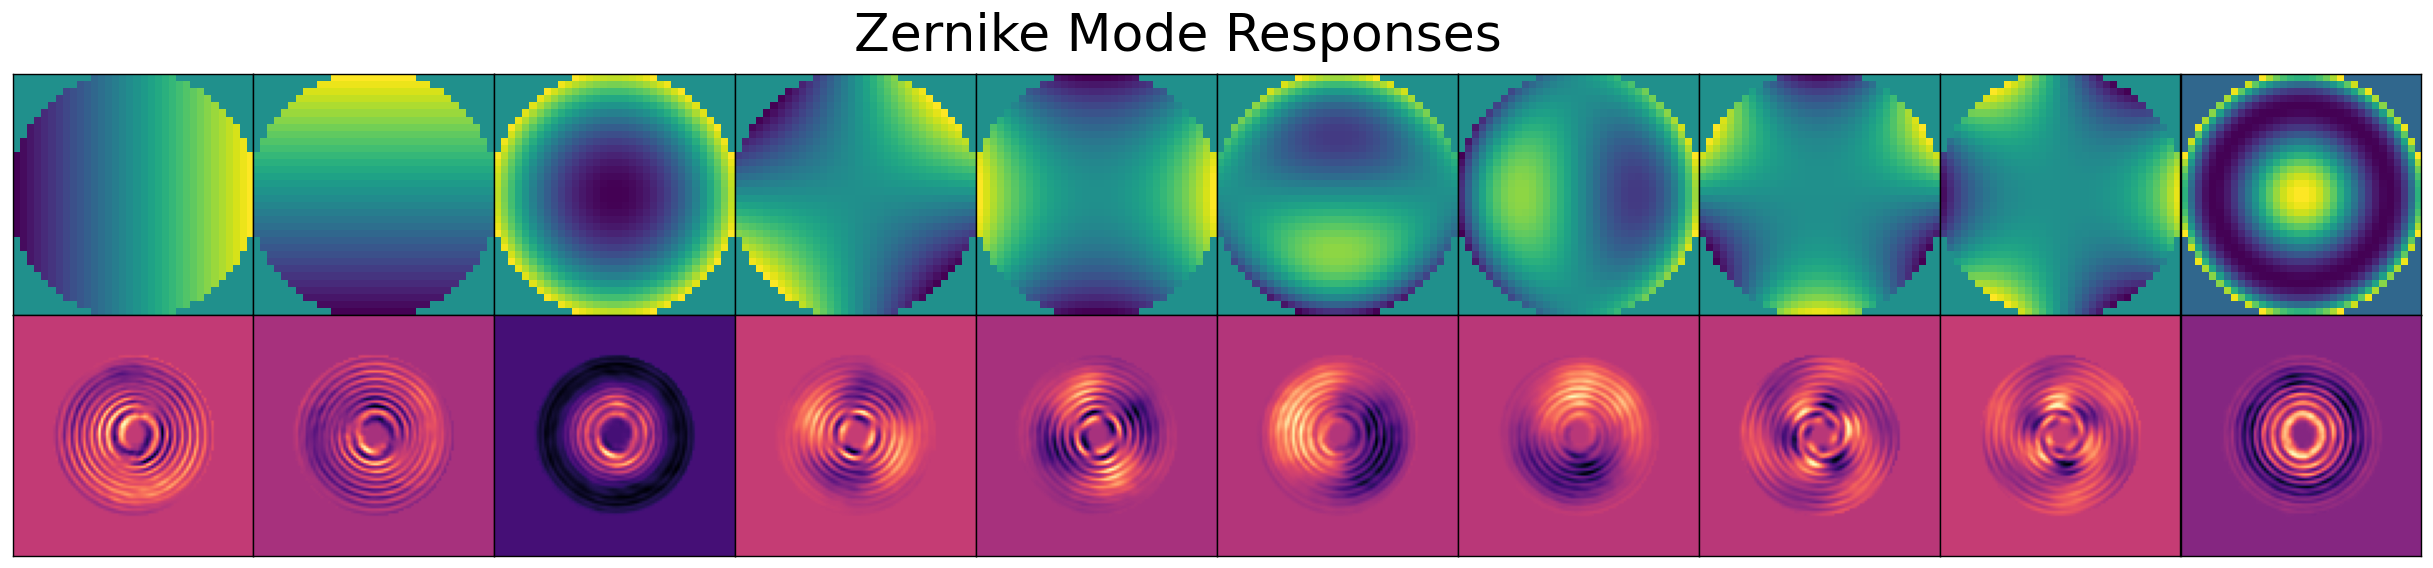

In [6]:
reload(llowfsc)
llowfsc.plot_responses(
    zernike_modes, 
    z_response_cube*llowfsc_mask,
    title='Zernike Mode Responses',
    title_fs=30,
)
# llowfsc.plot_responses(zernike_modes[10:], z_response_cube[10:])

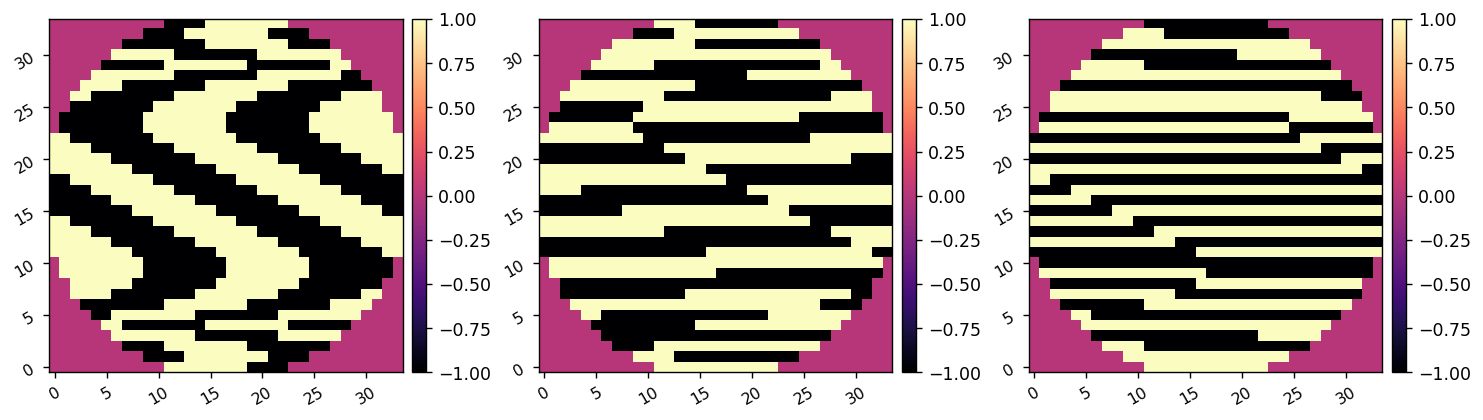

In [8]:
hadamard_modes = utils.create_hadamard_modes(M.dm_mask)
had_modal_matrix = hadamard_modes[:, M.dm_mask]
imshow3(hadamard_modes[8], hadamard_modes[80], hadamard_modes[800])

In [9]:
reload(llowfsc)
M.reset_dm()
M.setattr('use_vortex', True)

h_rm, h_response_cube = llowfsc.calibrate_without_fsm(
    M, 
    hadamard_modes, 
    llowfsc_mask, 
    amps=3e-9, 
    # plot=True,
)

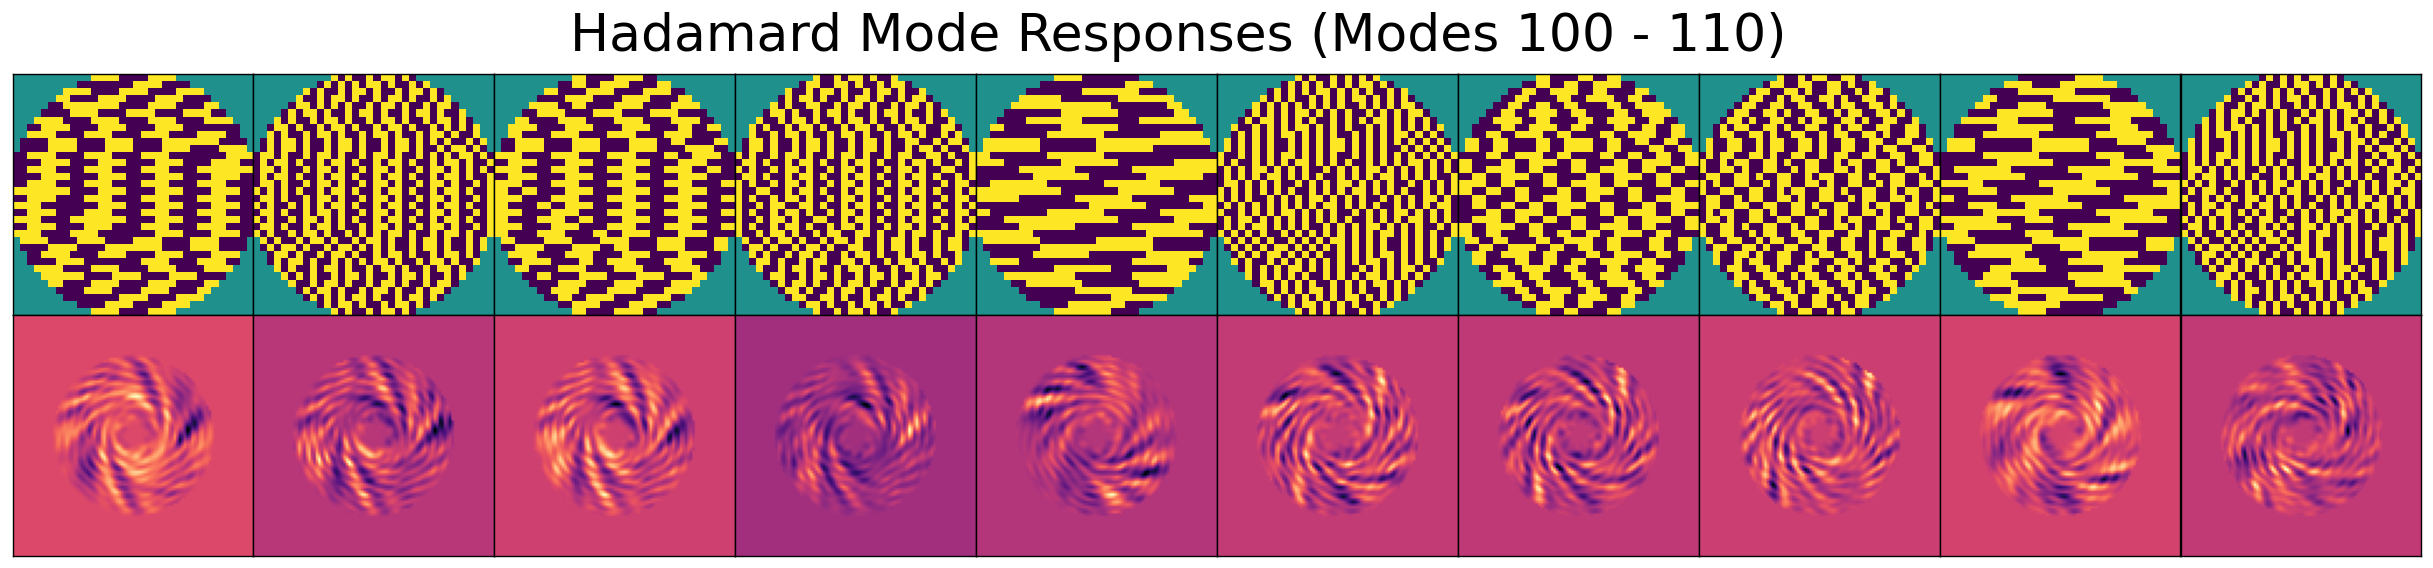

In [41]:
reload(llowfsc)
istart = 100
llowfsc.plot_responses(
    hadamard_modes[istart:], 
    h_response_cube[istart:]*llowfsc_mask,
    title=f'Hadamard Mode Responses (Modes {istart} - {istart+10})',
    title_fs=30,
    # dpi=150,
)

In [14]:
reload(llowfsc)
M.reset_dm()
M.setattr('use_vortex', True)

Ncutoff = 256
hsvd_control_modes = hsvd_dm_modes[:Ncutoff]
hsvd_modal_matrix = hsvd_control_modes[:, M.dm_mask]

hsvd_rm, hsvd_response_cube = llowfsc.calibrate_without_fsm(
    M, 
    hsvd_control_modes, 
    llowfsc_mask, 
    amps=3e-9, 
    # plot=True,
)


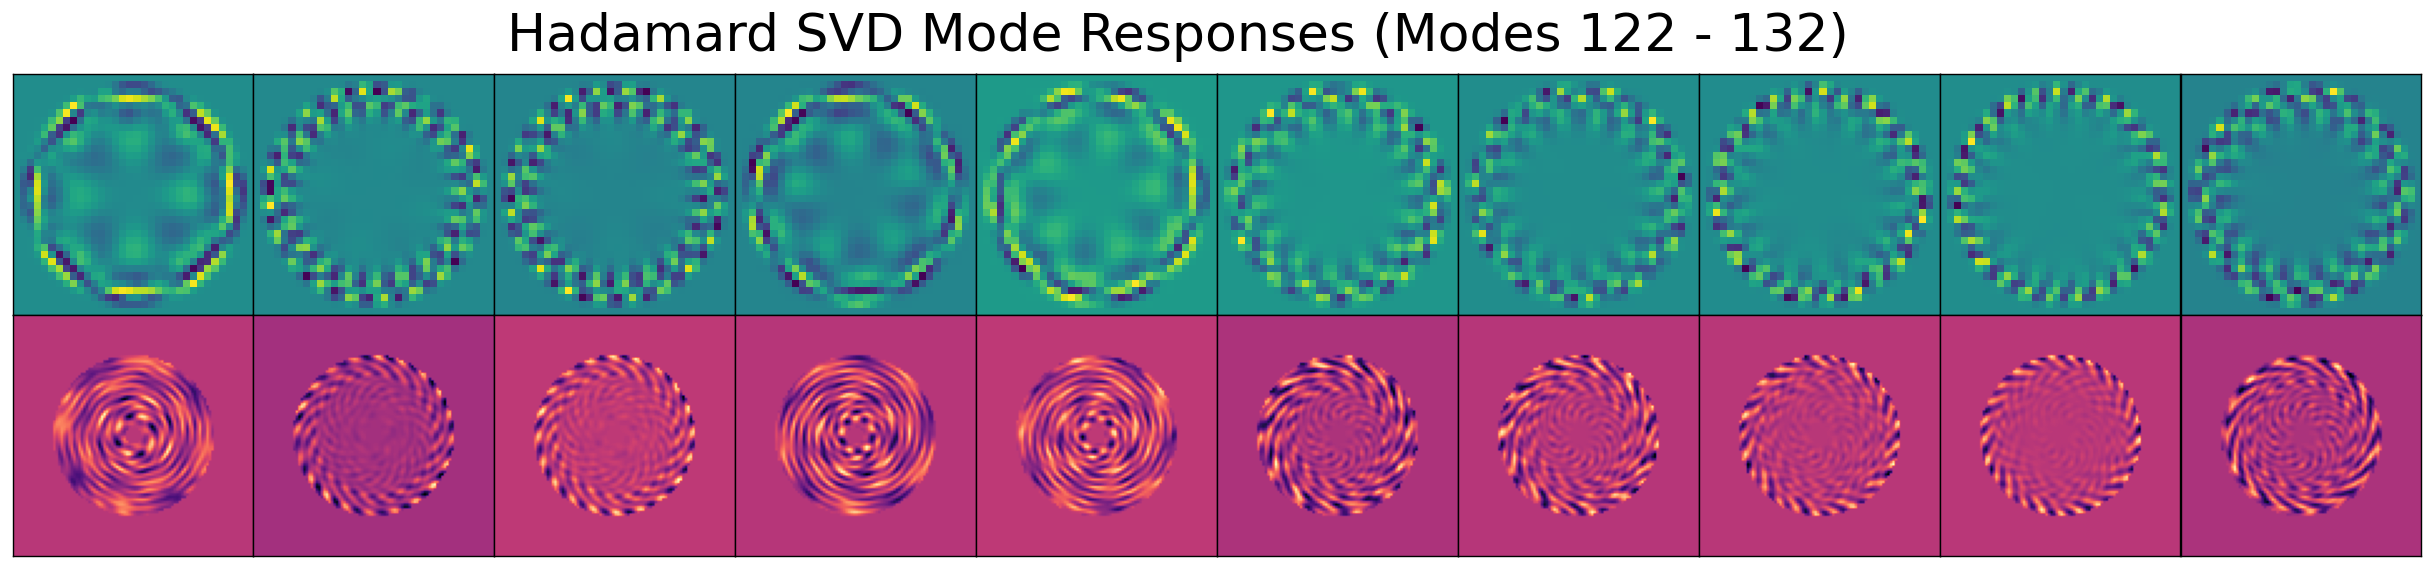

In [42]:
reload(llowfsc)
istart = 122
llowfsc.plot_responses(
    hsvd_control_modes[istart:], 
    hsvd_response_cube[istart:]*llowfsc_mask,
    title=f'Hadamard SVD Mode Responses (Modes {istart} - {istart+10})',
    title_fs=30,
)

In [29]:
wfe_modes = utils.create_zernike_modes(M.APERTURE, nmodes=10, remove_modes=1)

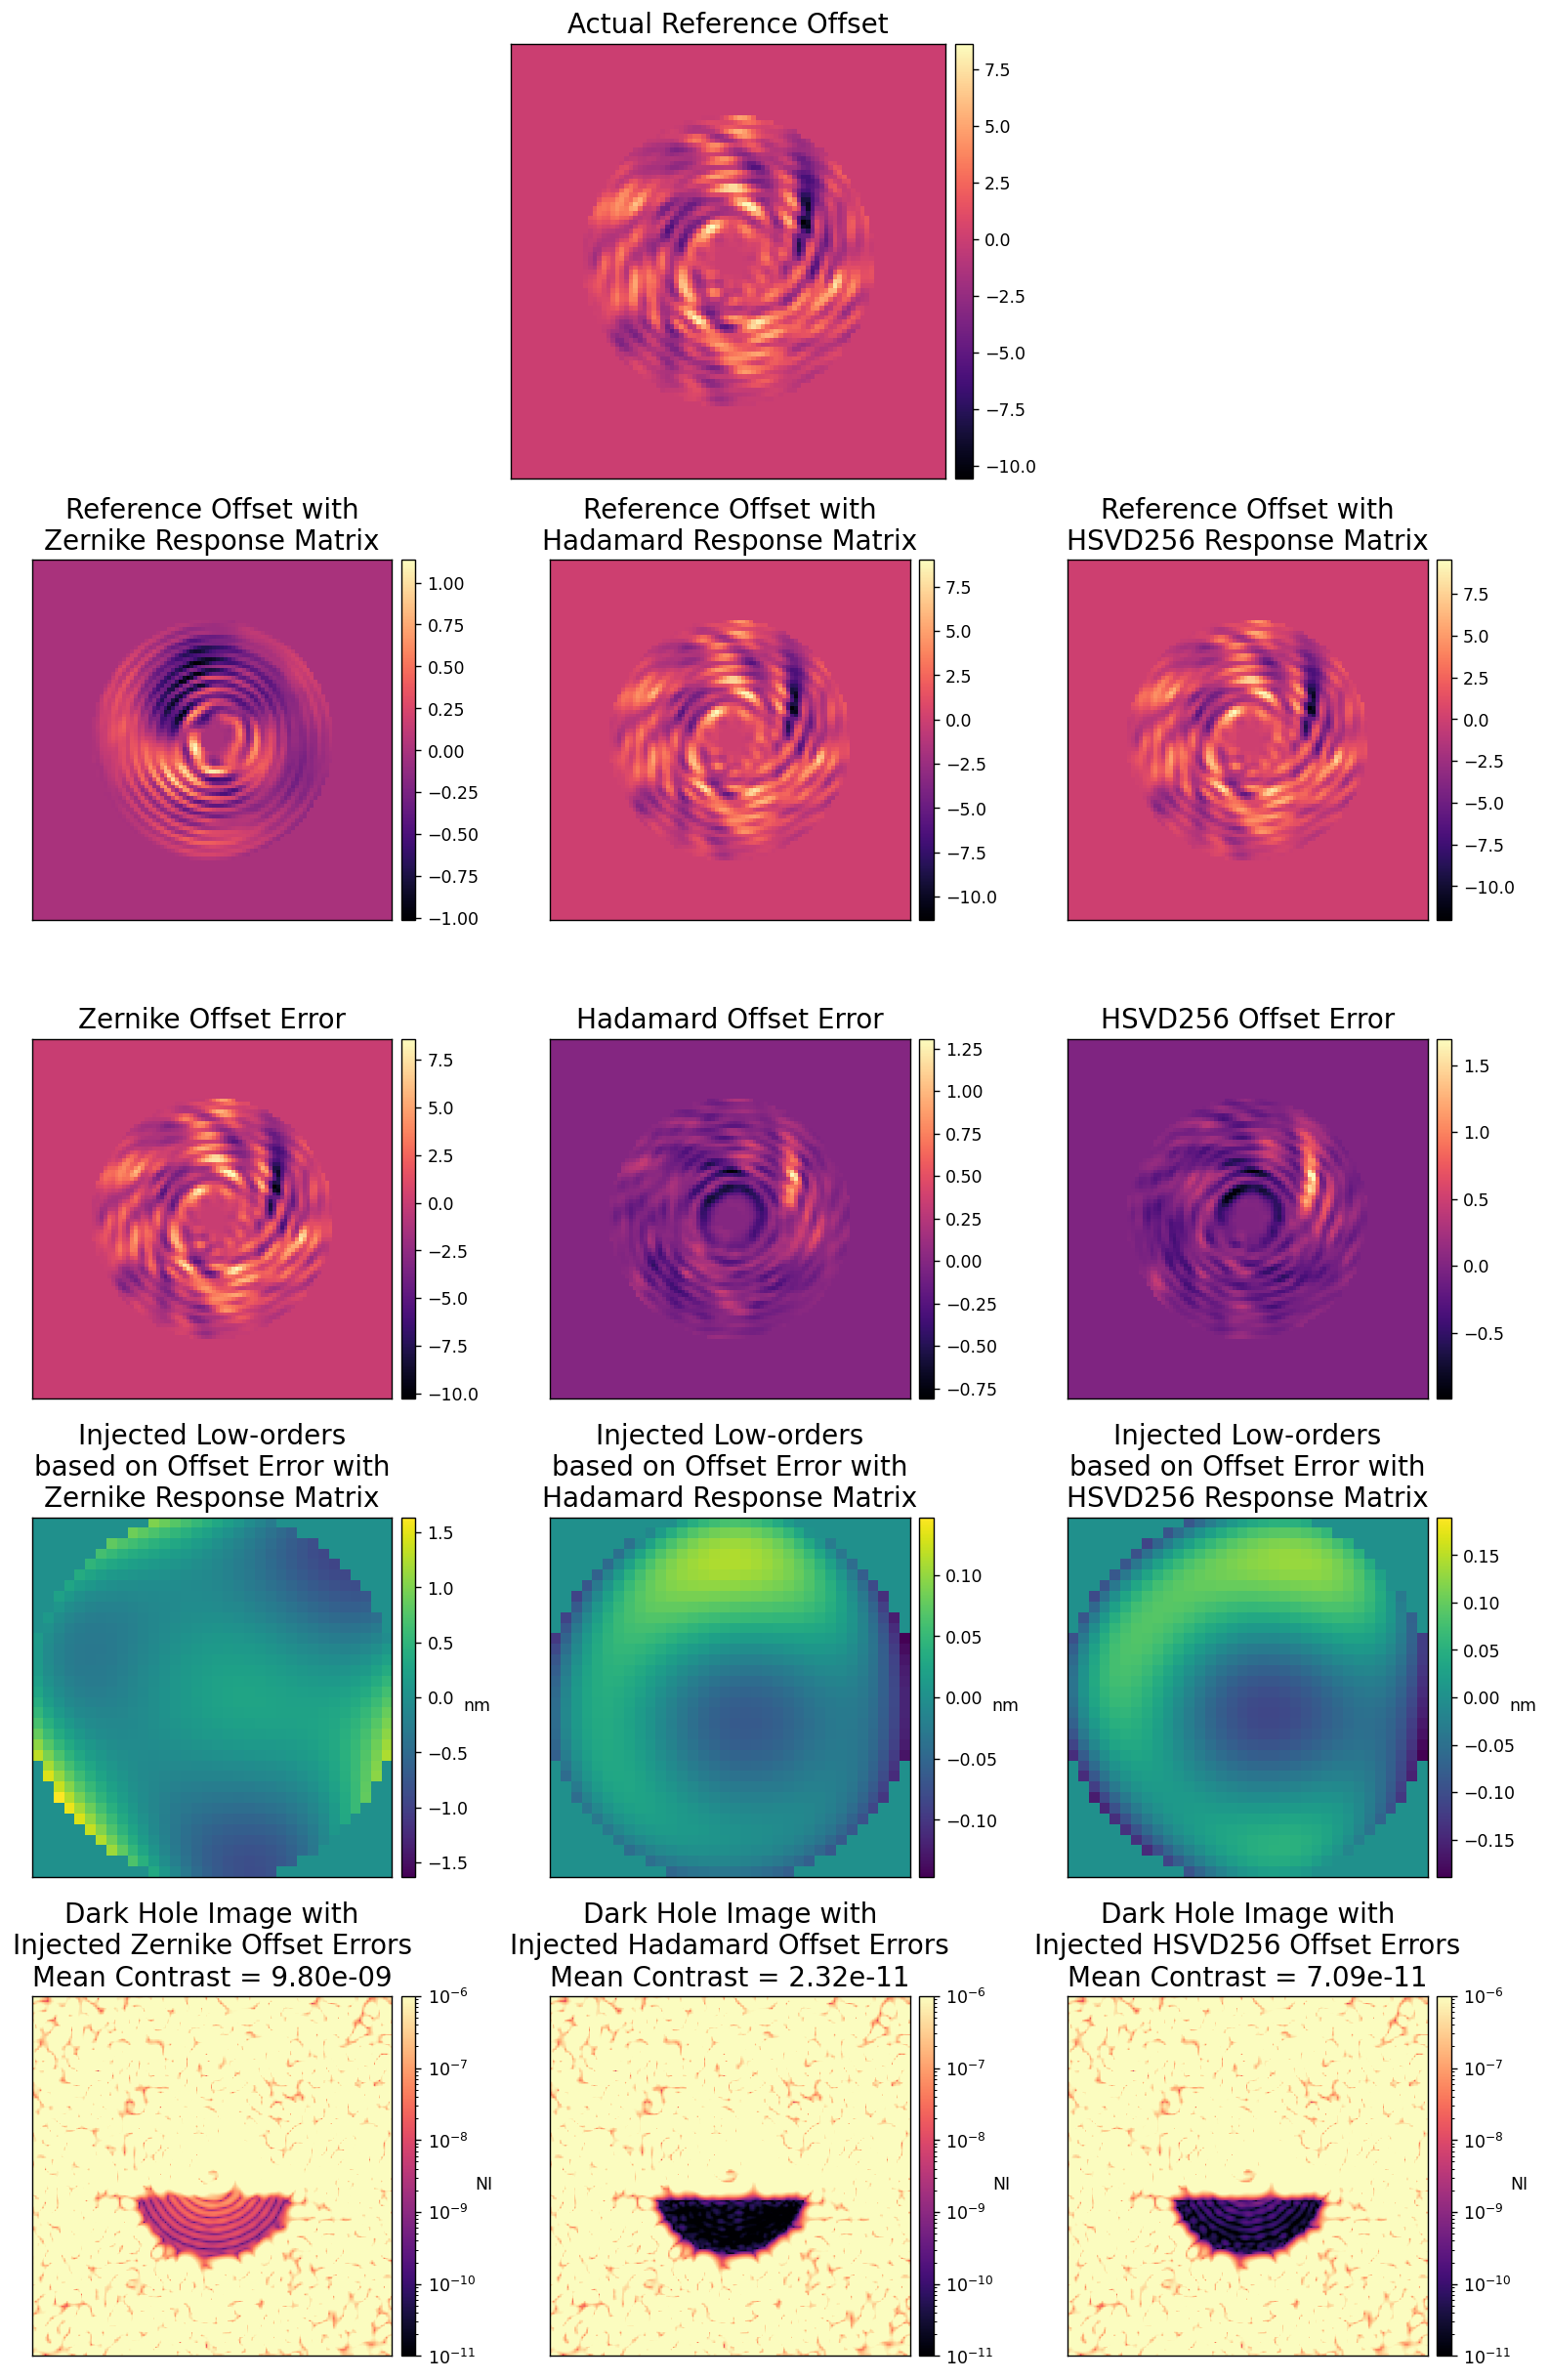

In [ ]:
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']
M.reset_dm()
M.add_dm(dh_command, 3)
ref_offset_truth = (M.snap_camlo() - camlo_im_ref) * llowfsc_mask

ref_offset_zer = xp.zeros_like(camlo_im_ref)
ref_offset_zer[llowfsc_mask] = z_rm.dot( zer_modal_matrix.dot( dh_command[M.dm_mask] ) / 952 )

ref_offset_had = xp.zeros_like(camlo_im_ref)
ref_offset_had[llowfsc_mask] = h_rm.dot( had_modal_matrix.dot( dh_command[M.dm_mask] ) / 1024)

ref_offset_hsvd = xp.zeros_like(camlo_im_ref)
ref_offset_hsvd[llowfsc_mask] = hsvd_rm.dot( hsvd_modal_matrix.dot( dh_command[M.dm_mask] ) / 952)

control_matrix = utils.TikhonovInverse(z_rm, 0)

zer_error = llowfsc_mask*ref_offset_truth - ref_offset_zer
zer_coeff = control_matrix.dot(zer_error[llowfsc_mask])
# zer_offset_lo_opd = xp.sum( zer_coeff[:, None, None] * wfe_modes, axis=0)
# M.PREFPM_OPD = wfe_data['PREFPM_OPD'] + zer_offset_lo_opd
zer_offset_lo_opd = xp.sum( zer_coeff[:, None, None] * zernike_modes, axis=0)
M.set_dm(zer_offset_lo_opd, 2)
camsci_im_zer_offset = M.snap_camsci()
contrast_zer_offset = xp.mean(camsci_im_zer_offset[dark_hole_mask])

had_error = llowfsc_mask*ref_offset_truth - ref_offset_had
had_coeff = control_matrix.dot(had_error[llowfsc_mask])
# had_offset_lo_opd = xp.sum( had_coeff[:, None, None] * wfe_modes, axis=0)
# M.PREFPM_OPD = wfe_data['PREFPM_OPD'] + had_offset_lo_opd
had_offset_lo_opd = xp.sum( had_coeff[:, None, None] * zernike_modes, axis=0)
M.set_dm(had_offset_lo_opd, 2)
camsci_im_had_offset = M.snap_camsci()
contrast_had_offset = xp.mean(camsci_im_had_offset[dark_hole_mask])

hsvd_error = llowfsc_mask*ref_offset_truth - ref_offset_hsvd
hsvd_coeff = control_matrix.dot(hsvd_error[llowfsc_mask])
# hsvd_offset_lo_opd = xp.sum( hsvd_coeff[:, None, None] * wfe_modes, axis=0)
# M.PREFPM_OPD = wfe_data['PREFPM_OPD'] + hsvd_offset_lo_opd
hsvd_offset_lo_opd = xp.sum( hsvd_coeff[:, None, None] * zernike_modes, axis=0)
M.set_dm(hsvd_offset_lo_opd, 2)
camsci_im_hsvd_offset = M.snap_camsci()
contrast_hsvd_offset = xp.mean(camsci_im_hsvd_offset[dark_hole_mask])

figsize = (15,25)
dpi = 125
title_fz = 16

fig = plt.figure(figsize=figsize, dpi=dpi)
gs = GridSpec(5, 3, figure=fig)

# TRUE REFERENCE OFFSET
ax = fig.add_subplot(gs[0, :])
im = ax.imshow(ensure_np_array(ref_offset_truth), cmap='magma')
ax.set_title('Actual Reference Offset', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
# cbar.ax.set_ylabel('m', rotation=0, labelpad=7)
# ax.set_position([0.05, 0.505, 0.3, 0.3]) 

# PREDICTED OFFSETS
ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(ensure_np_array(ref_offset_zer), cmap='magma')
ax.set_title('Reference Offset with\nZernike Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)

ax = fig.add_subplot(gs[1,1])
im = ax.imshow(ensure_np_array(ref_offset_had), cmap='magma')
ax.set_title('Reference Offset with\nHadamard Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)

ax = fig.add_subplot(gs[1,2])
im = ax.imshow(ensure_np_array(ref_offset_hsvd), cmap='magma')
ax.set_title(f'Reference Offset with\nHSVD{Ncutoff} Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)

# REFERNCE OFFSET ERRORS
ax = fig.add_subplot(gs[2, 0])
im = ax.imshow(ensure_np_array(zer_error), cmap='magma')
ax.set_title('Zernike Offset Error', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)

ax = fig.add_subplot(gs[2,1])
im = ax.imshow(ensure_np_array(had_error), cmap='magma')
ax.set_title('Hadamard Offset Error', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)

ax = fig.add_subplot(gs[2,2])
im = ax.imshow(ensure_np_array(hsvd_error), cmap='magma')
ax.set_title(f'HSVD{Ncutoff} Offset Error', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)

# OFFSET ERROR OPDs
ax = fig.add_subplot(gs[3,0])
im = ax.imshow(ensure_np_array(zer_offset_lo_opd)*1e9, cmap='viridis', norm=CenteredNorm())
ax.set_title('Injected Low-orders\nbased on Offset Error with\nZernike Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('nm', rotation=0, labelpad=5)

ax = fig.add_subplot(gs[3,1])
im = ax.imshow(ensure_np_array(had_offset_lo_opd)*1e9, cmap='viridis', norm=CenteredNorm())
ax.set_title('Injected Low-orders\nbased on Offset Error with\nHadamard Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('nm', rotation=0, labelpad=5)

ax = fig.add_subplot(gs[3,2])
im = ax.imshow(ensure_np_array(hsvd_offset_lo_opd)*1e9, cmap='viridis', norm=CenteredNorm())
ax.set_title(f'Injected Low-orders\nbased on Offset Error with\nHSVD{Ncutoff} Response Matrix', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('nm', rotation=0, labelpad=5)

ax = fig.add_subplot(gs[4,0])
im = ax.imshow(ensure_np_array(camsci_im_zer_offset), cmap='magma', norm=LogNorm(vmin=1e-11, vmax=1e-6))
ax.set_title(f'Dark Hole Image with\nInjected Zernike Offset Errors\nMean Contrast = {contrast_zer_offset:.2e}', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=5)

ax = fig.add_subplot(gs[4,1])
im = ax.imshow(ensure_np_array(camsci_im_had_offset), cmap='magma', norm=LogNorm(vmin=1e-11, vmax=1e-6))
ax.set_title(f'Dark Hole Image with\nInjected Hadamard Offset Errors\nMean Contrast = {contrast_had_offset:.2e}', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=5)

ax = fig.add_subplot(gs[4,2])
im = ax.imshow(ensure_np_array(camsci_im_hsvd_offset), cmap='magma', norm=LogNorm(vmin=1e-11, vmax=1e-6))
ax.set_title(f'Dark Hole Image with\nInjected HSVD{Ncutoff} Offset Errors\nMean Contrast = {contrast_hsvd_offset:.2e}', fontsize=title_fz)
ax.set_xticks([])
ax.set_yticks([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('NI', rotation=0, labelpad=5)

plt.subplots_adjust(wspace=0.35, hspace=0.1)


# Now run a time series with each of the reference offsets for a more full evaluation.

0.0005
0.002 500.0
(10, 5251)


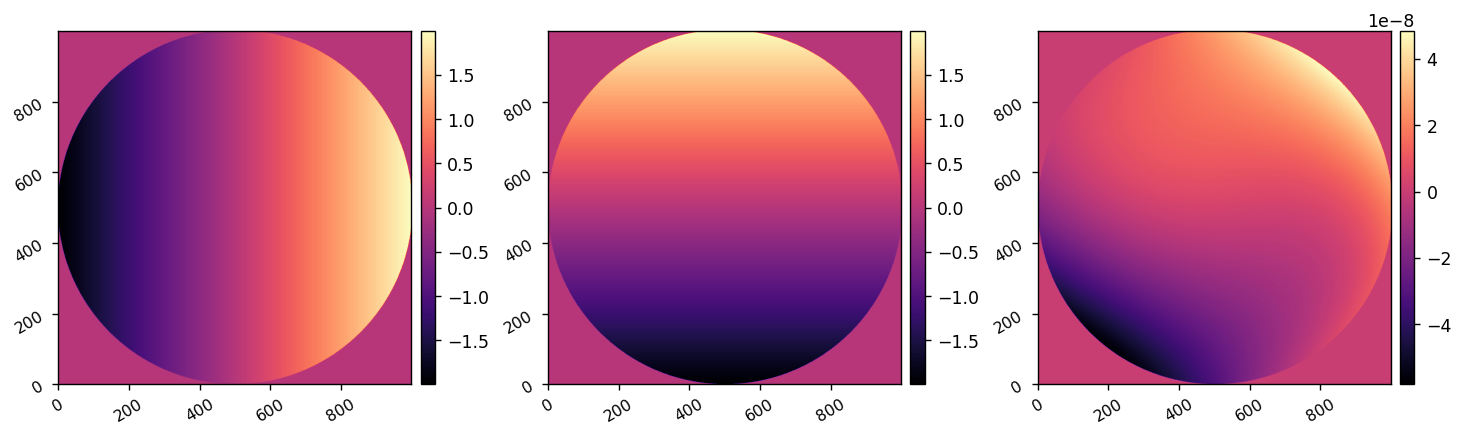

In [8]:
from scoob_llowfsc import psds
import copy
reload(psds)

fmax = 1000*u.Hz
tmax = 5*u.s
tmax = 10.5*u.s
# tmax = 1*u.hour
# tmax = 5*u.hour

wfe_modes_rms = np.array(2*[10e-9] + 8*[2.5e-9])
# wfe_modes_rms = np.array(2*[10e-9] + 8*[2.5e-9])
# knee_freqs = np.array([0.1]*2 + [0.01]*8) * u.Hz
knee_freqs = np.array([1]*2 + [0.1]*8) * u.Hz
slope = 4

N_wfe_modes = len(wfe_modes_rms)
wfe_modes = utils.create_zernike_modes(M.APERTURE, nmodes=N_wfe_modes, remove_modes=1)

freqs, times = psds.generate_freqs(Nf=2**22+1, f_max=fmax)
delT = times[1] - times[0]

wfe_psds = xp.zeros((N_wfe_modes, len(freqs)))
wfe_time_series = xp.zeros((N_wfe_modes, len(times)))
seeds = 123 + np.linspace(0, N_wfe_modes-1, N_wfe_modes).astype(int)
for i in range(N_wfe_modes):
    f_knee = knee_freqs[i]
    psd = psds.kneePSD(freqs, 1, f_knee.to_value(u.Hz), slope)
    wfe_psds[i] = copy.copy(psd)
    coeff = psds.generate_time_series(psd, fmax, rms=1, seed=seeds[i])
    sign = 1 if xp.random.randn(1)>0 else -1
    wfe_time_series[i] = wfe_modes_rms[i] * sign * xp.array(coeff)

buffer = 0.0001
wfe_time_series = wfe_time_series[:, times<tmax.to_value(u.s)+buffer]
times = times[times<tmax.to_value(u.s)+buffer]
delT = times[1] - times[0]
print(delT)

times, wfe_time_series = (times[::4], wfe_time_series[:, ::4])
# times, wfe_time_series = (times[::8], wfe_time_series[:, ::8])
# times, wfe_time_series = (times[::8], wfe_time_series[:, ::10])
# times, wfe_time_series = (times[::20], wfe_time_series[:, ::20])
delT = times[1] - times[0]
print(delT, 1/delT)

print(wfe_time_series.shape)

lo_wfe = xp.sum( wfe_time_series[:, 500, None, None] * wfe_modes, axis=0)
imshow3(wfe_modes[0], wfe_modes[1], lo_wfe)

/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/psds.py:149: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[0].set_xlim(psd_xlims)


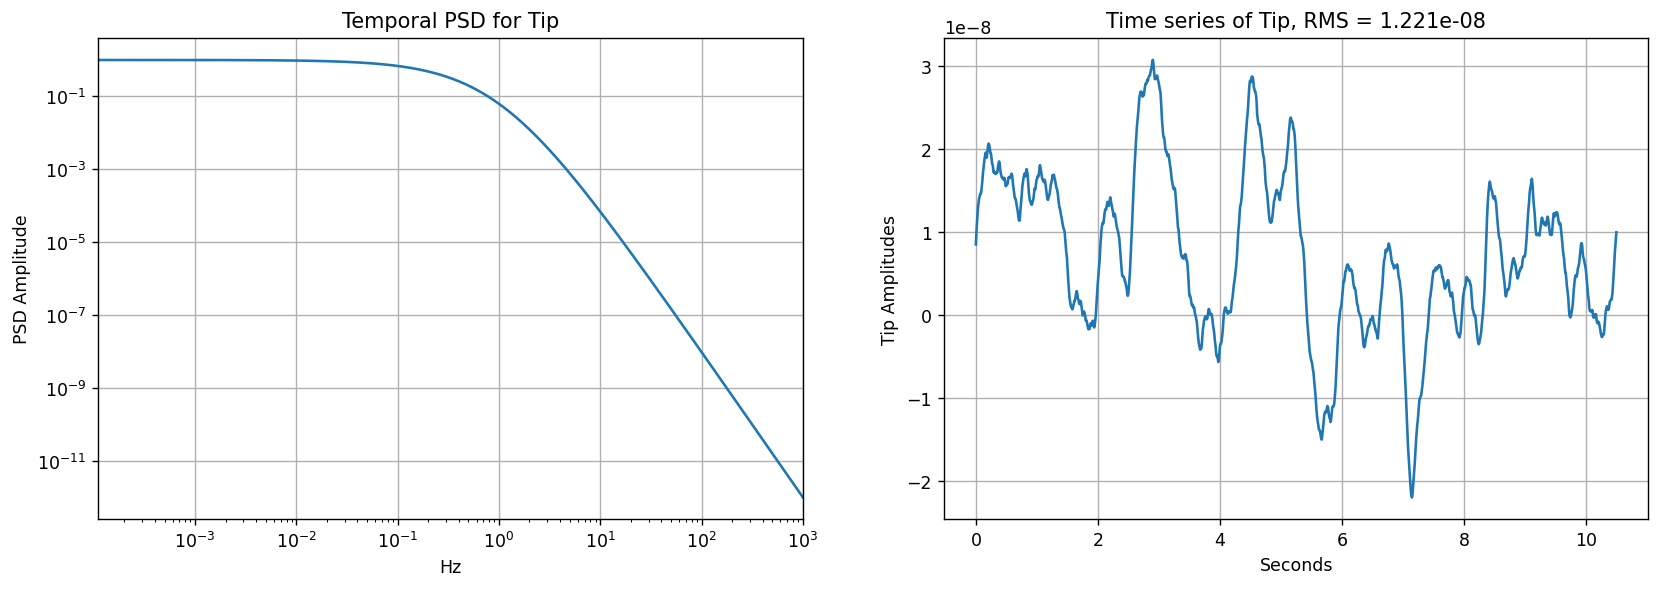

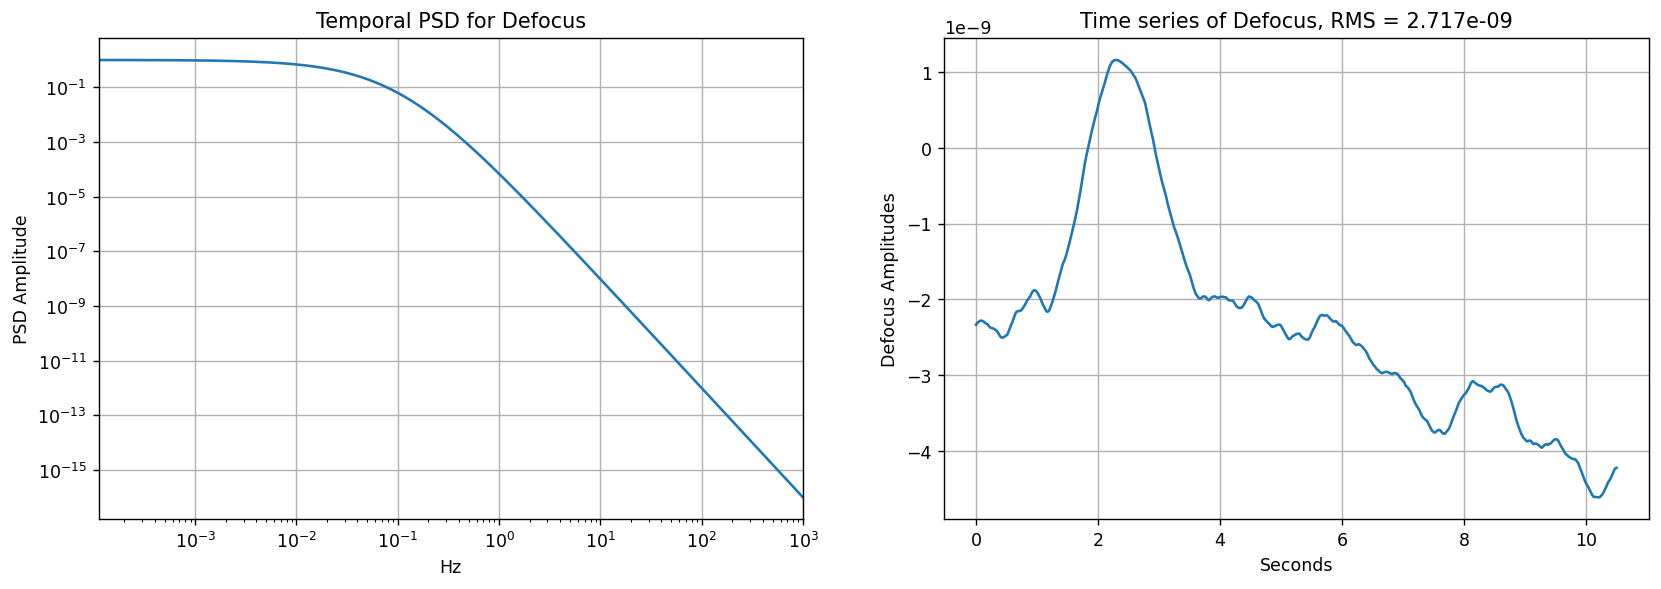

In [9]:
reload(psds)
i = 1
psd = wfe_psds[i]
coeff = wfe_time_series[i]

psds.plot_psd_and_time_series(
    freqs, psd,
    times, coeff,
    psd_name='for Tip',
    coeff_name='Tip',
    psd_xlims=[freqs.min(), 1000],
    # coeff_xlims=[0, 3600],
    # coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)

i = 3
psd = wfe_psds[i]
coeff = wfe_time_series[i]

psds.plot_psd_and_time_series(
    freqs, psd,
    times, coeff,
    psd_name='for Defocus',
    coeff_name='Defocus',
    psd_xlims=[freqs.min(), 1000],
    # coeff_xlims=[0, 3600],
    # coeff_xticks=np.arange(0,3600+1,600),
    figsize=(16,5),
)

In [11]:
reload(llowfsc)
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']
M.zero_fsm()
M.reset_dm()
M.add_dm(dh_command, 3)

M.NCAMLO = 1

# ref_offset_hsvd = xp.zeros_like(camlo_im_ref)
# ref_offset_hsvd[llowfsc_mask] = hsvd_rm.dot( hsvd_modal_matrix.dot( dh_command[M.dm_mask] ) / 952)

# gains = xp.array(2*[0.75] + 8*[0.05])
gains = xp.array(2*[0.75] + 8*[0.25])

control_matrix = utils.TikhonovInverse(z_rm, 0)

llowfsc_dict = llowfsc.run(
    M, 
    wfe_data['PREFPM_AMP'], wfe_data['PREFPM_OPD'],
    camlo_im_ref,
    xp.zeros_like(camlo_im_ref),
    # ref_offset_zer,
    # ref_offset_had,
    # ref_offset_hsvd,
    llowfsc_mask, 
    control_matrix, 
    # wfe_time_series[:, :100],
    # wfe_time_series[:, :200],
    wfe_time_series, 
    wfe_modes, 
    zernike_modes,
    channel=2,
    gain=gains,  
    # leakage=0.01,
    # plot=True, 
    # camsci_vmax=1e-6,
    # camsci_vmin=1e-10,
    # sleep=1,
    # plot_all=True,
)

llowfsc_dict.update({
    'dark_hole_mask':dark_hole_mask,
    'llowfsc_mask':llowfsc_mask,
})

Starting LLOWFSC control-loop simulation
	Iteration 5250/5250 completed in 267.468s
LLOWFSC simulation complete.


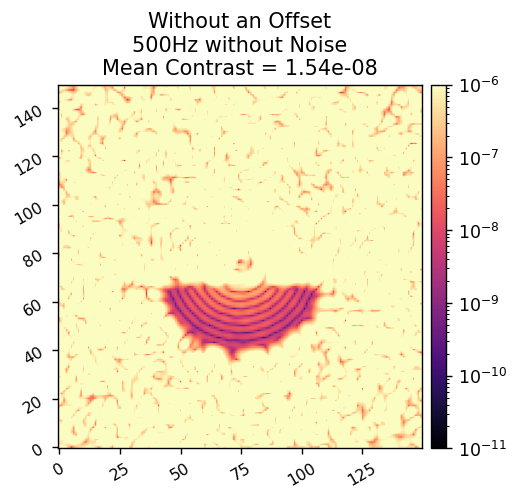

In [12]:
mean_camsci_im_no_offset = xp.mean(llowfsc_dict['camsci_ims'][50:], axis=0)
mean_contrast_no_offset = xp.mean( mean_camsci_im_no_offset[dark_hole_mask])

imshow1(
    mean_camsci_im_no_offset, 
    f'Without an Offset\n500Hz without Noise\nMean Contrast = {mean_contrast_no_offset:.2e}', 
    lognorm=1, 
    vmin=1e-11, vmax=1e-6,
)

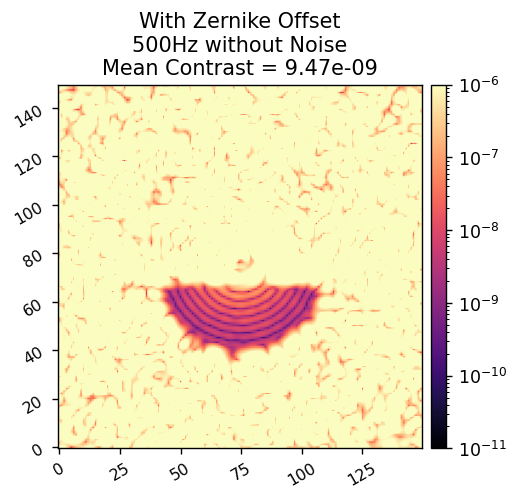

In [56]:
mean_camsci_im_zer = xp.mean(llowfsc_dict['camsci_ims'][50:], axis=0)
mean_contrast_zer = xp.mean( mean_camsci_im_zer[dark_hole_mask])

imshow1(
    mean_camsci_im_zer, 
    f'With Zernike Offset\n500Hz without Noise\nMean Contrast = {mean_contrast_zer:.2e}', 
    lognorm=1, 
    vmin=1e-11, vmax=1e-6,
)

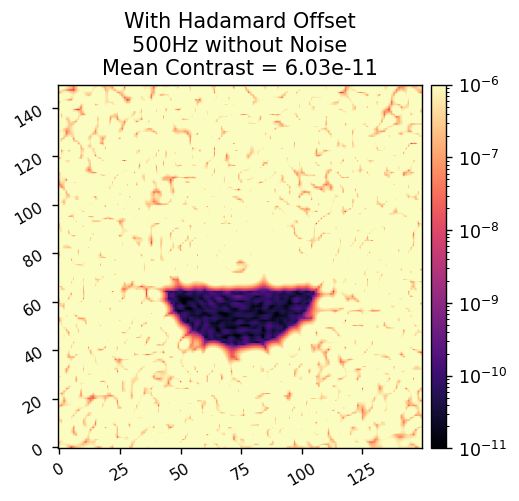

In [ ]:
mean_camsci_im_had = xp.mean(llowfsc_dict['camsci_ims'][50:], axis=0)
mean_contrast_had = xp.mean( mean_camsci_im_had[dark_hole_mask])

imshow1(
    mean_camsci_im_had, 
    f'With Hadamard Offset\n500Hz without Noise\nMean Contrast = {mean_contrast_had:.2e}', 
    lognorm=1, 
    vmin=1e-11, vmax=1e-6,
)

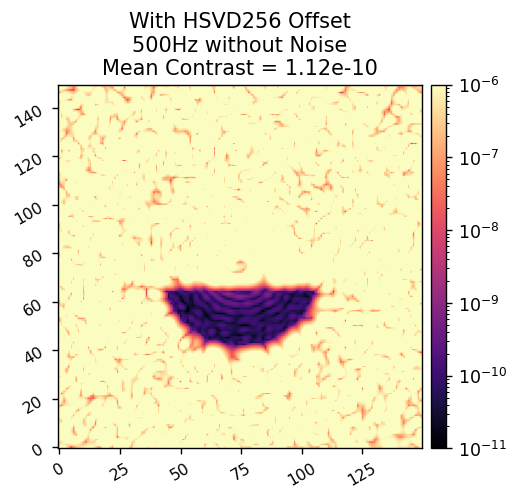

In [58]:
mean_camsci_im_hsvd = xp.mean(llowfsc_dict['camsci_ims'][50:], axis=0)
mean_contrast_hsvd = xp.mean( mean_camsci_im_hsvd[dark_hole_mask])

imshow1(
    mean_camsci_im_hsvd, 
    f'With HSVD{Ncutoff} Offset\n500Hz without Noise\nMean Contrast = {mean_contrast_hsvd:.2e}', 
    lognorm=1, 
    vmin=1e-11, vmax=1e-6,
)

In [61]:
mean_contrasts = ensure_np_array( xp.array( [mean_contrast_zer, mean_contrast_had, mean_contrast_hsvd] ) )
mean_camsci_ims = ensure_np_array( xp.array( [mean_camsci_im_zer, mean_camsci_im_had, mean_camsci_im_hsvd] ) )

example_llowfsc_ims = {
    'mean_camsci_ims':mean_camsci_ims,
    'mean_contrasts':mean_contrasts,
}

utils.save_pickle('sim-data/example_llowfsc_ims.pkl', example_llowfsc_ims)

Saved data to:  sim-data/example_llowfsc_ims.pkl


# Plot the PSD and the time series

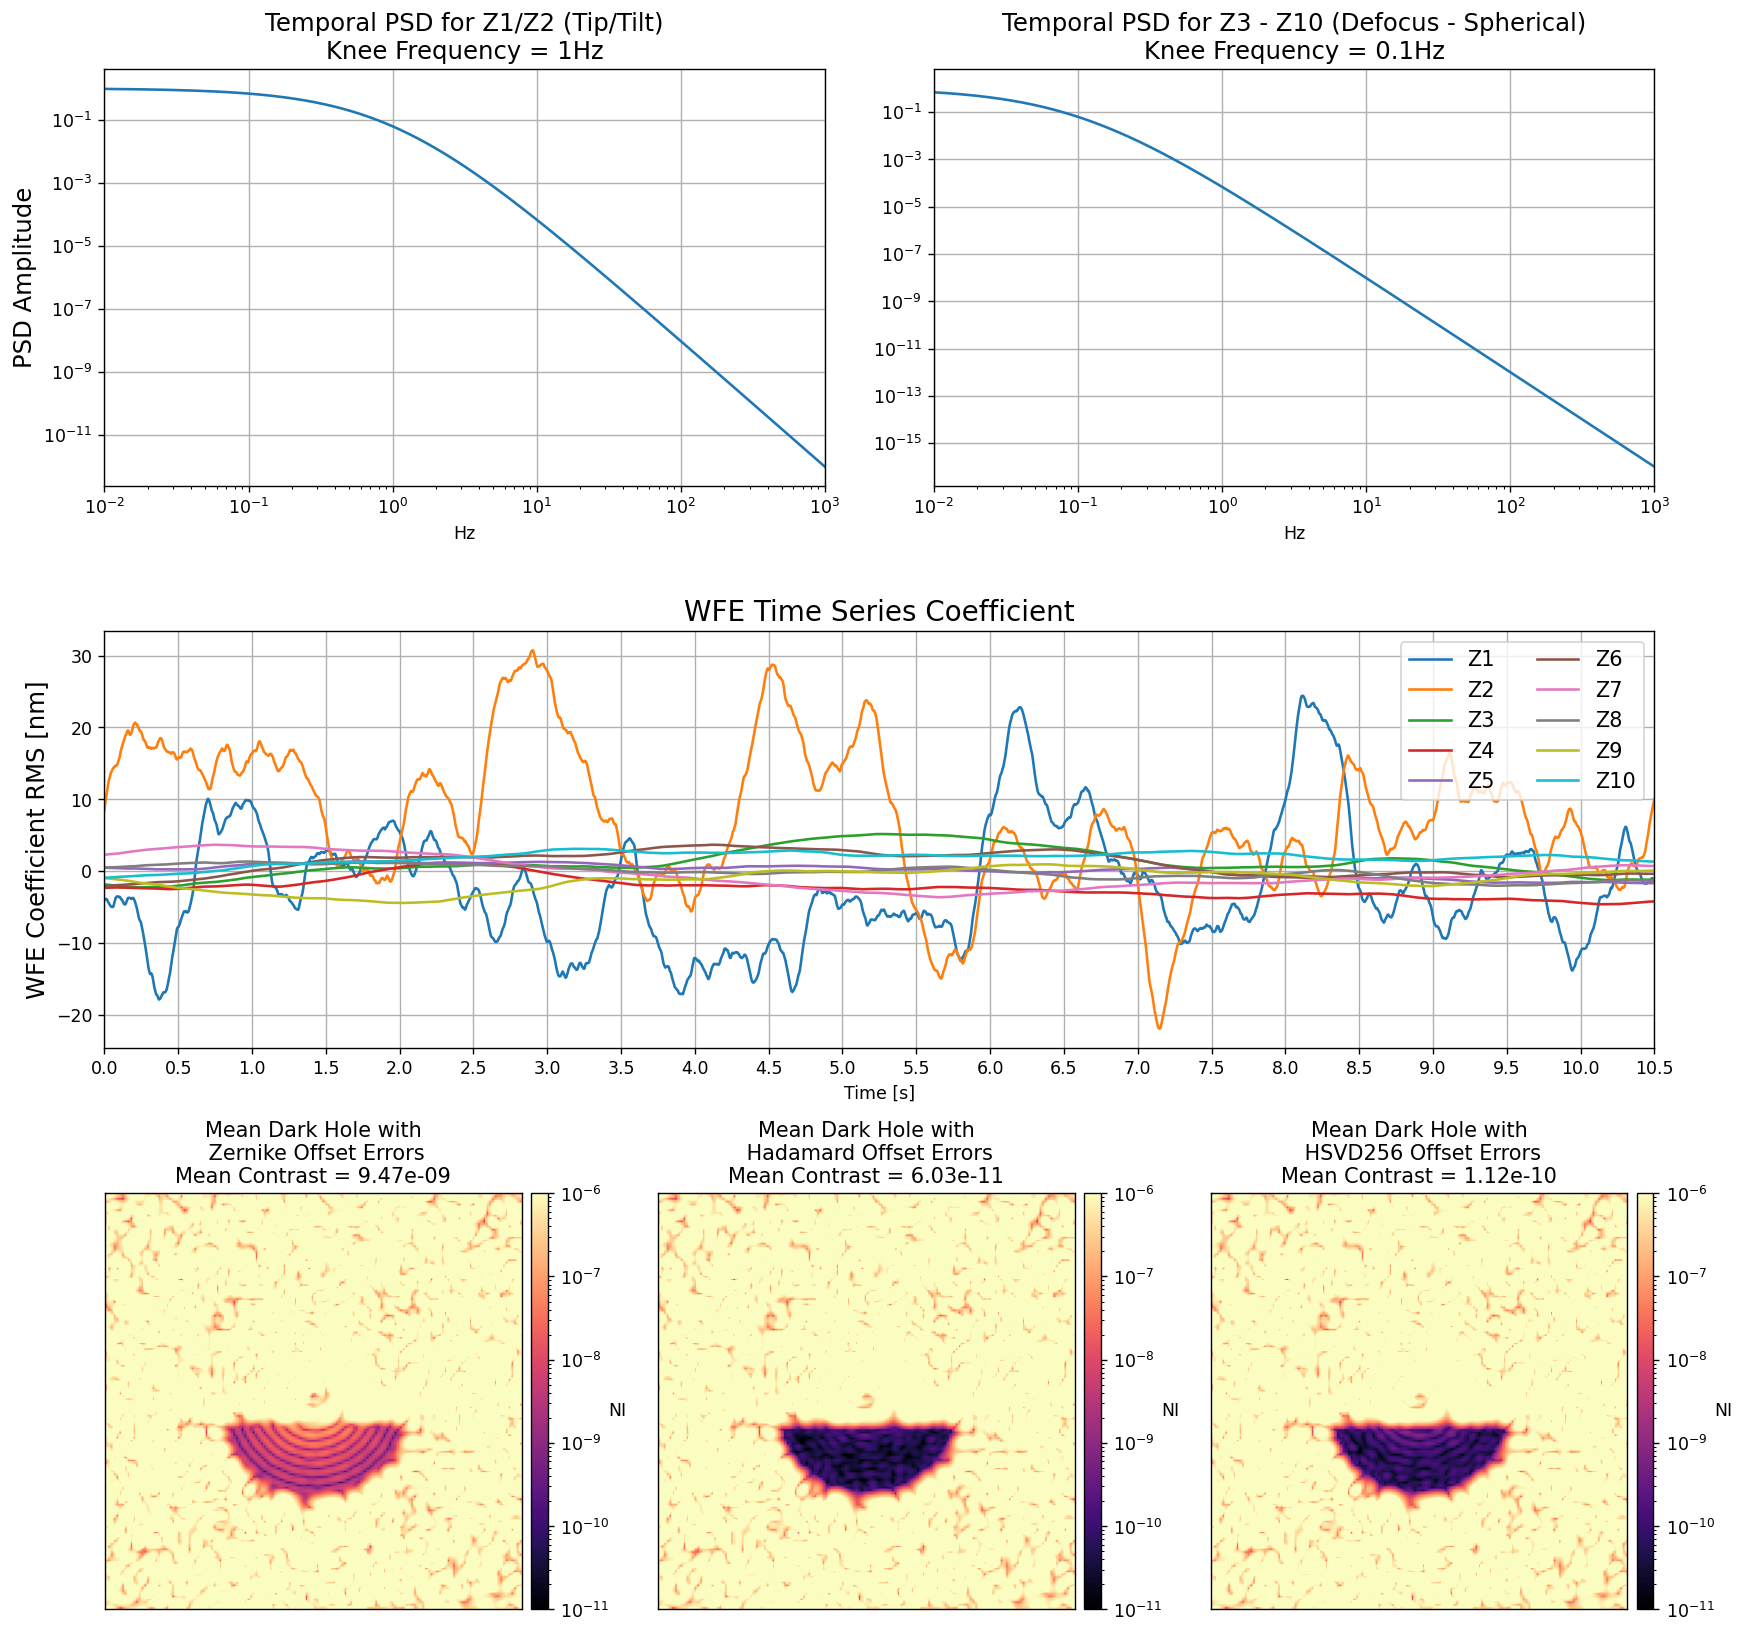

In [99]:
freqs = ensure_np_array(freqs)
psd1 = ensure_np_array(wfe_psds[0])
psd2 = ensure_np_array(wfe_psds[2])
# psd_xlims = [freqs.min(), 1000]
psd_xlims = [1e-2, 1000]
psd_ylims = None

offset_names = ['Zernike', 'Hadamard', 'HSVD256']
ext = M.camsci_pxscl_lamDc * M.ncamsci/2
camsci_extent = [-ext, ext, -ext, ext]
mean_contrasts = ensure_np_array( xp.array( [mean_contrast_zer, mean_contrast_had, mean_contrast_hsvd] ) )
mean_camsci_ims = ensure_np_array( xp.array( [mean_camsci_im_zer, mean_camsci_im_had, mean_camsci_im_hsvd] ) )

times = ensure_np_array(times)
wfe_time_series = ensure_np_array(wfe_time_series)

series_xlims = [0, times.max()]
series_ylims = None
series_xticks = np.arange(0, times.max()+0.01, 0.5)
figsize = (16,16)
dpi = 125

fig = plt.figure(figsize=figsize, dpi=dpi)
# gs = GridSpec(3, 2, figure=fig)
gs = GridSpec(3, 6, figure=fig)

ax = fig.add_subplot(gs[0,:3])
ax.plot(freqs,psd1)
ax.set_title(f'Temporal PSD for Z1/Z2 (Tip/Tilt)\nKnee Frequency = {1}Hz', fontsize=14)
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylabel(f'PSD Amplitude', fontsize=14)
ax.grid()
ax.set_xlim(psd_xlims)
ax.set_ylim(psd_ylims)
ax.set_xlabel('Hz')

ax = fig.add_subplot(gs[0,3:])
ax.plot(freqs,psd2)
ax.set_title(f'Temporal PSD for Z3 - Z10 (Defocus - Spherical)\nKnee Frequency = {0.1}Hz', fontsize=14)
ax.set_yscale("log")
ax.set_xscale("log")
# ax.set_ylabel(f'PSD Amplitude')
ax.grid()
ax.set_xlim(psd_xlims)
ax.set_ylim(psd_ylims)
ax.set_xlabel('Hz')

ax = fig.add_subplot(gs[1,:])
for i in range(N_wfe_modes):
    ax.plot(times, wfe_time_series[i]*1e9, label=f'Z{i+1}')
ax.set_title(f'WFE Time Series Coefficient', fontsize=16)
ax.set_ylabel(f'WFE Coefficient RMS [nm]', fontsize=14)
ax.grid()
ax.set_xlim(series_xlims)
ax.set_ylim(series_ylims)
ax.set_xticks(series_xticks)
ax.set_xlabel('Time [s]')
ax.legend(ncol=2, loc='upper right', fontsize=12)
# ax.legend(bbox_to_anchor=[0.95, 0.85])

for i in range(3):
    if i==0:
        ax = fig.add_subplot(gs[2,0:2])
    elif i==1:
        ax = fig.add_subplot(gs[2,2:4])
    elif i==2:
        ax = fig.add_subplot(gs[2,4:])
    im = ax.imshow(mean_camsci_ims[i], cmap='magma', norm=LogNorm(vmin=1e-11, vmax=1e-6), extent=camsci_extent)
    ax.set_title(f'Mean Dark Hole with\n {offset_names[i]} Offset Errors\nMean Contrast = {mean_contrasts[i]:.2e}')
    ax.set_xticks([])
    ax.set_yticks([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.set_ylabel('NI', rotation=0, labelpad=5)

plt.subplots_adjust(wspace=0.65, hspace=0.35)


In [76]:
arr = np.arange(6)
i = 0
arr[i:i+2]

array([0, 1])